# 🏠 Satellite Imagery-Based Property Valuation

In [1]:
# ==========================================================================
# IMPORTS AND CONFIGURATION
# ==========================================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import os
from PIL import Image
import warnings
warnings.filterwarnings('ignore')

# Paths - adjust these to your setup
PROJECT_ROOT = Path('.')  # Current directory
DATA_DIR = PROJECT_ROOT / 'data' / 'raw'
IMAGES_DIR = PROJECT_ROOT / 'data' / 'images'
RESULTS_DIR = PROJECT_ROOT / 'results'
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

# Constants
SEATTLE_CENTER_LAT = 47.6062
SEATTLE_CENTER_LONG = -122.3321
CURRENT_YEAR = 2025

# Plot style
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 11

print("Configuration loaded")
print(f"Project root: {PROJECT_ROOT.absolute()}")

Configuration loaded
Project root: d:\OneDrive\Documents\exp_satellite_valuation


---
## 1. Data Loading
---

In [2]:
# ==========================================================================
# LOAD DATA
# ==========================================================================

# Try multiple possible locations
train_paths = [
    DATA_DIR / 'train.csv',
    PROJECT_ROOT / 'train.csv',
    Path('data/train.csv'),
    Path('train.csv')
]

train_df = None
for path in train_paths:
    if path.exists():
        train_df = pd.read_csv(path)
        print(f"Loaded training data from: {path}")
        break

if train_df is None:
    raise FileNotFoundError("Could not find train.csv. Please ensure data is in data/raw/ directory.")

# Basic info
print(f"\nTraining data shape: {train_df.shape}")
print(f"\nColumns: {list(train_df.columns)}")
print(f"\nData types:")
print(train_df.dtypes)

Loaded training data from: data\raw\train.csv

Training data shape: (16209, 21)

Columns: ['id', 'date', 'price', 'bedrooms', 'bathrooms', 'sqft_living', 'sqft_lot', 'floors', 'waterfront', 'view', 'condition', 'grade', 'sqft_above', 'sqft_basement', 'yr_built', 'yr_renovated', 'zipcode', 'lat', 'long', 'sqft_living15', 'sqft_lot15']

Data types:
id                 int64
date              object
price              int64
bedrooms           int64
bathrooms        float64
sqft_living        int64
sqft_lot           int64
floors           float64
waterfront         int64
view               int64
condition          int64
grade              int64
sqft_above         int64
sqft_basement      int64
yr_built           int64
yr_renovated       int64
zipcode            int64
lat              float64
long             float64
sqft_living15      int64
sqft_lot15         int64
dtype: object


In [11]:
# === imports, config & quick checks ===
import os, math, random
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import mean_squared_error, r2_score
from PIL import Image

sns.set(style="whitegrid", context="notebook", font_scale=1.0)
%matplotlib inline

# Try to import config with safe fallback
try:
    from config import TRAIN_FILE, IMAGES_ZOOM_16_DIR, IMAGES_ZOOM_17_DIR, IMAGES_ZOOM_18_DIR, RESULTS_DIR
    IMAGES_ZOOM_16_DIR = Path(IMAGES_ZOOM_16_DIR)
    IMAGES_ZOOM_17_DIR = Path(IMAGES_ZOOM_17_DIR)
    IMAGES_ZOOM_18_DIR = Path(IMAGES_ZOOM_18_DIR)
    RESULTS_DIR = Path(RESULTS_DIR)
except Exception:
    # Fallback: guess local paths
    TRAIN_FILE = Path("data/raw/train.csv")
    IMAGES_ZOOM_16_DIR = Path("data/images/zoom_16")
    IMAGES_ZOOM_17_DIR = Path("data/images/zoom_17")
    IMAGES_ZOOM_18_DIR = Path("data/images/zoom_18")
    RESULTS_DIR = Path("results")
    print("Warning: failed to import config — using default guessed paths")

print("Train rows:", len(train_df))
print("Images zoom18 exists:", IMAGES_ZOOM_18_DIR.exists())
RESULTS_DIR.mkdir(parents=True, exist_ok=True)


Train rows: 16209
Images zoom18 exists: True


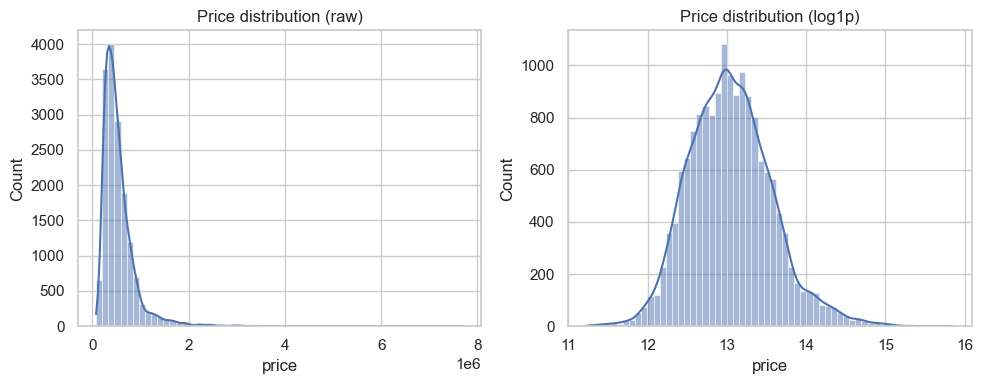

         count           mean            std      min       25%       50%  \
price  16209.0  537470.282744  360303.577357  75000.0  320000.0  450000.0   

            75%        max  
price  640000.0  7700000.0  


In [12]:
# === price distribution raw + log ===
plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
sns.histplot(train_df['price'], bins=60, kde=True)
plt.title('Price distribution (raw)')
plt.subplot(1,2,2)
sns.histplot(np.log1p(train_df['price']), bins=60, kde=True)
plt.title('Price distribution (log1p)')
plt.tight_layout()
plt.show()

# summary stats
print(train_df['price'].describe().to_frame().T)


In [3]:
# ==========================================================================
# BASIC STATISTICS
# ==========================================================================

print("Price Statistics:")
print(f"  Min:    ${train_df['price'].min():,.0f}")
print(f"  Max:    ${train_df['price'].max():,.0f}")
print(f"  Mean:   ${train_df['price'].mean():,.0f}")
print(f"  Median: ${train_df['price'].median():,.0f}")
print(f"  Std:    ${train_df['price'].std():,.0f}")

print(f"\nMissing values:")
missing = train_df.isnull().sum()
if missing.sum() > 0:
    print(missing[missing > 0])
else:
    print("  No missing values!")

# Key segment statistics
print(f"\nKey Segments:")
print(f"  Waterfront: {(train_df['waterfront'] == 1).sum()} ({(train_df['waterfront'] == 1).mean()*100:.1f}%)")
print(f"  High grade (>=10): {(train_df['grade'] >= 10).sum()} ({(train_df['grade'] >= 10).mean()*100:.1f}%)")
print(f"  >$1M: {(train_df['price'] > 1000000).sum()} ({(train_df['price'] > 1000000).mean()*100:.1f}%)")

Price Statistics:
  Min:    $75,000
  Max:    $7,700,000
  Mean:   $537,470
  Median: $450,000
  Std:    $360,304

Missing values:
  No missing values!

Key Segments:
  Waterfront: 113 (0.7%)
  High grade (>=10): 1220 (7.5%)
  >$1M: 1070 (6.6%)


---
## 2. Exploratory Data Analysis (EDA)
---

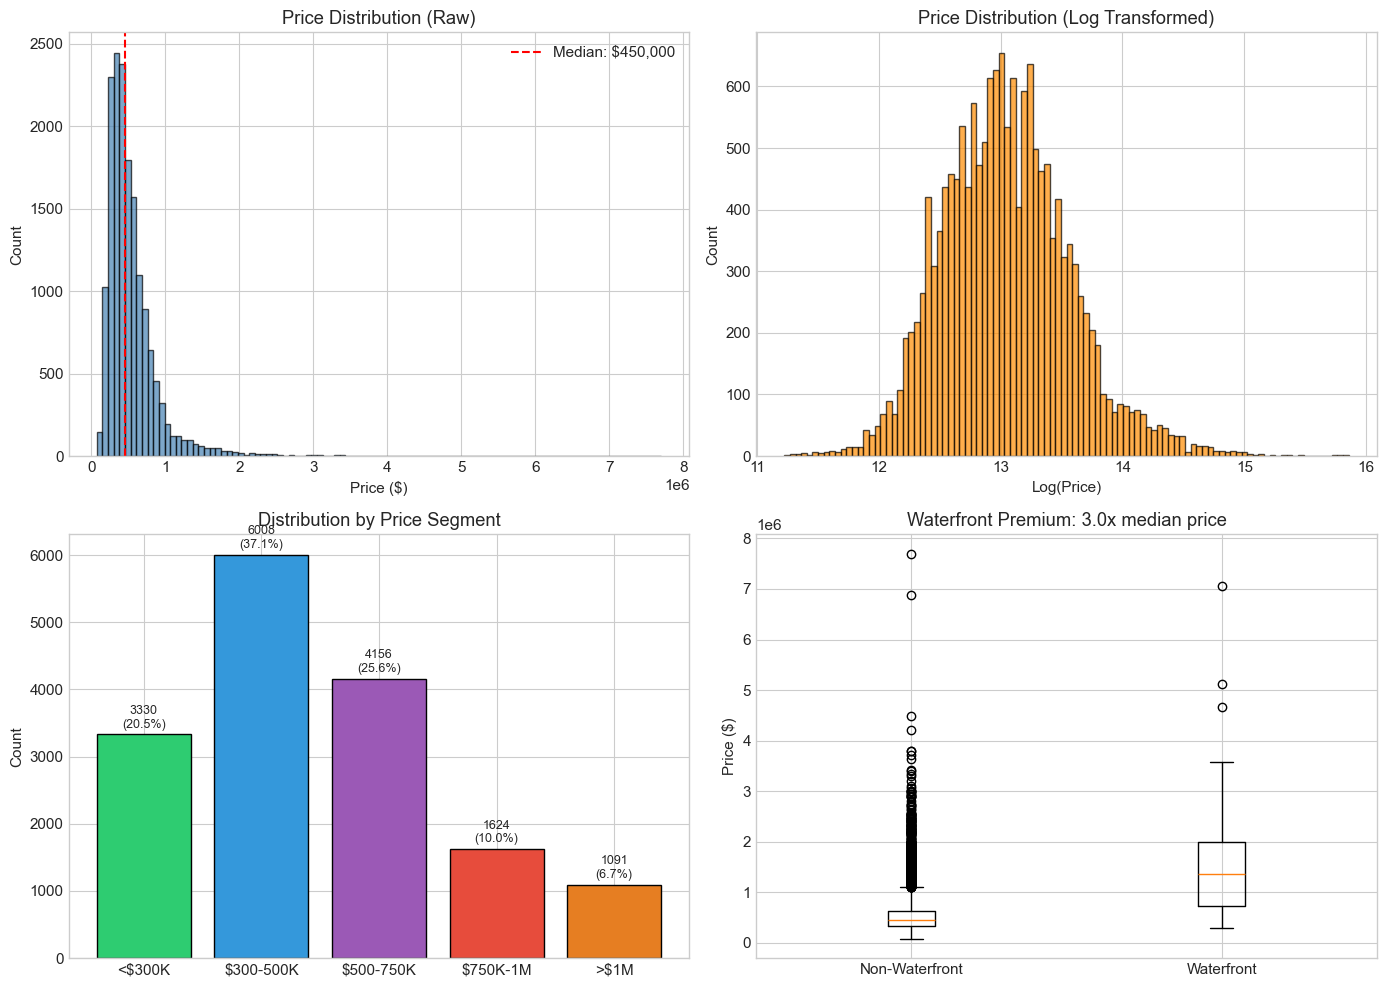


📊 KEY INSIGHT: Heavy right skew with >$1M properties dominating RMSE
   This is why segment-aware modeling is critical!


In [4]:
# ==========================================================================
# PRICE DISTRIBUTION ANALYSIS
# ==========================================================================

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Raw price distribution
ax1 = axes[0, 0]
ax1.hist(train_df['price'], bins=100, color='steelblue', edgecolor='black', alpha=0.7)
ax1.axvline(train_df['price'].median(), color='red', linestyle='--', label=f'Median: ${train_df["price"].median():,.0f}')
ax1.set_xlabel('Price ($)')
ax1.set_ylabel('Count')
ax1.set_title('Price Distribution (Raw)')
ax1.legend()

# Log price distribution
ax2 = axes[0, 1]
ax2.hist(np.log1p(train_df['price']), bins=100, color='darkorange', edgecolor='black', alpha=0.7)
ax2.set_xlabel('Log(Price)')
ax2.set_ylabel('Count')
ax2.set_title('Price Distribution (Log Transformed)')

# Price by segment
ax3 = axes[1, 0]
segments = [
    ('<$300K', train_df['price'] < 300000),
    ('$300-500K', (train_df['price'] >= 300000) & (train_df['price'] < 500000)),
    ('$500-750K', (train_df['price'] >= 500000) & (train_df['price'] < 750000)),
    ('$750K-1M', (train_df['price'] >= 750000) & (train_df['price'] < 1000000)),
    ('>$1M', train_df['price'] >= 1000000),
]
segment_counts = [mask.sum() for name, mask in segments]
segment_names = [name for name, mask in segments]
colors = ['#2ecc71', '#3498db', '#9b59b6', '#e74c3c', '#e67e22']
ax3.bar(segment_names, segment_counts, color=colors, edgecolor='black')
ax3.set_ylabel('Count')
ax3.set_title('Distribution by Price Segment')
for i, (count, name) in enumerate(zip(segment_counts, segment_names)):
    ax3.text(i, count + 100, f'{count}\n({count/len(train_df)*100:.1f}%)', ha='center', fontsize=9)

# Waterfront premium
ax4 = axes[1, 1]
wf_prices = train_df[train_df['waterfront'] == 1]['price']
non_wf_prices = train_df[train_df['waterfront'] == 0]['price']
ax4.boxplot([non_wf_prices, wf_prices], labels=['Non-Waterfront', 'Waterfront'])
ax4.set_ylabel('Price ($)')
ax4.set_title(f'Waterfront Premium: {wf_prices.median()/non_wf_prices.median():.1f}x median price')

plt.tight_layout()
plt.savefig(RESULTS_DIR / 'price_distribution.png', dpi=150)
plt.show()

print("\n📊 KEY INSIGHT: Heavy right skew with >$1M properties dominating RMSE")
print("   This is why segment-aware modeling is critical!")

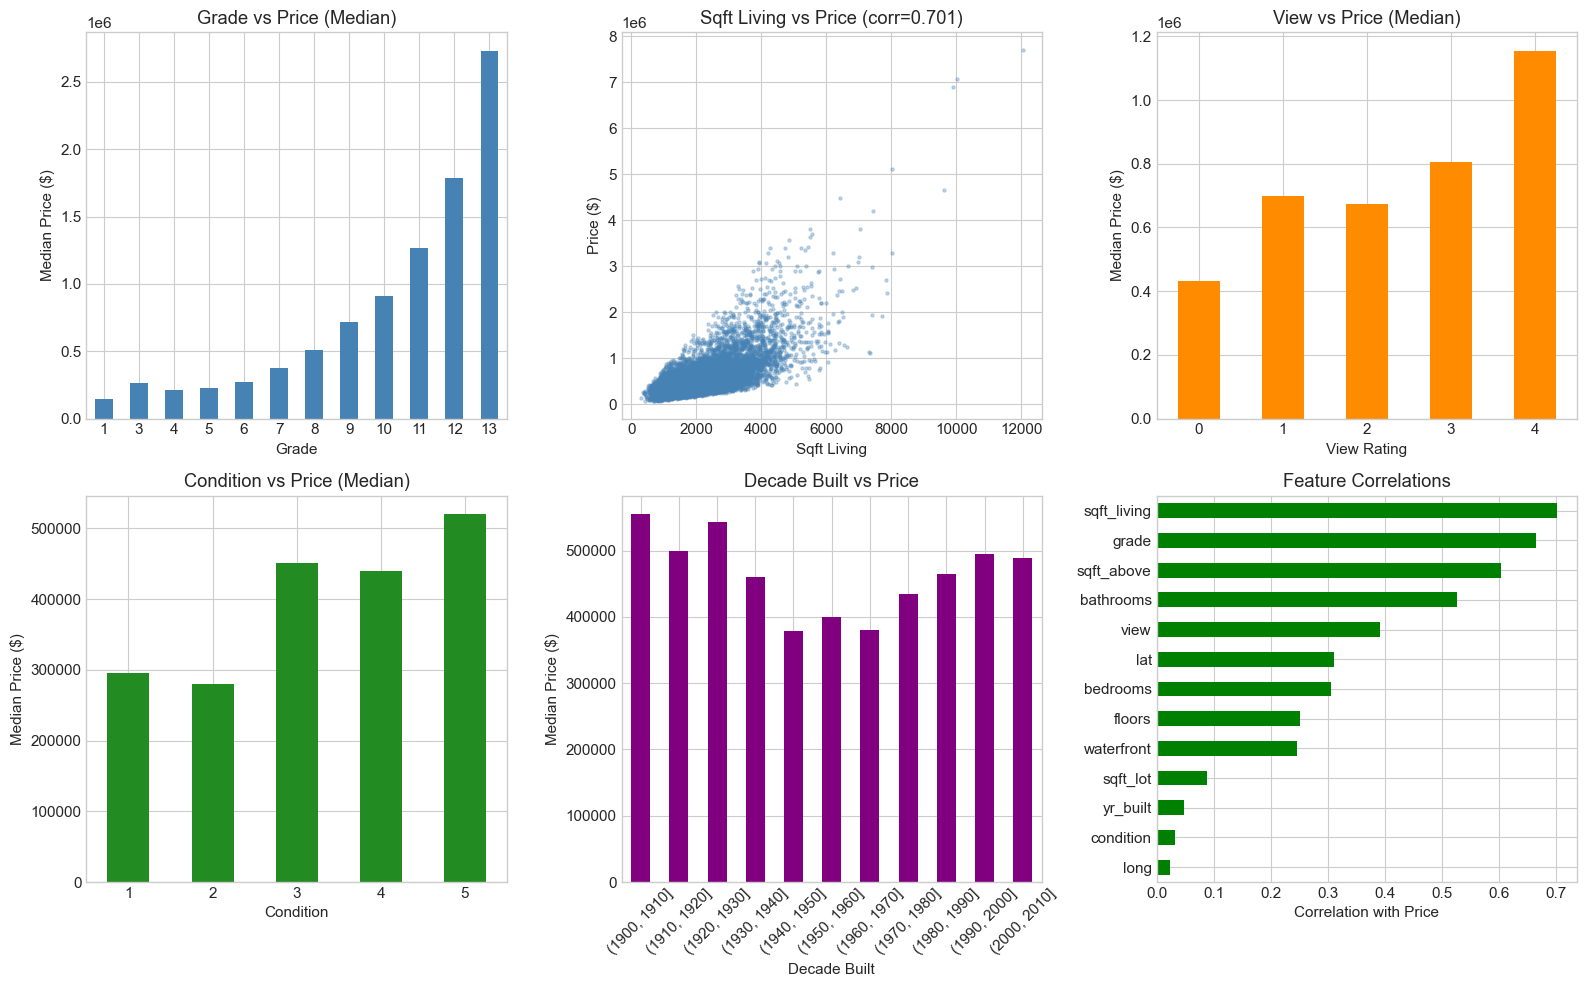


📊 KEY INSIGHTS:
   - Grade is the strongest predictor (quality matters most)
   - Sqft_living has strong linear relationship with price
   - View rating significantly impacts price
   - Location (lat/long) captures neighborhood effects


In [5]:
# ==========================================================================
# KEY FEATURE ANALYSIS
# ==========================================================================

fig, axes = plt.subplots(2, 3, figsize=(16, 10))

# Grade vs Price
ax1 = axes[0, 0]
train_df.groupby('grade')['price'].median().plot(kind='bar', ax=ax1, color='steelblue')
ax1.set_xlabel('Grade')
ax1.set_ylabel('Median Price ($)')
ax1.set_title('Grade vs Price (Median)')
ax1.tick_params(axis='x', rotation=0)

# Sqft vs Price
ax2 = axes[0, 1]
ax2.scatter(train_df['sqft_living'], train_df['price'], alpha=0.3, s=5, c='steelblue')
ax2.set_xlabel('Sqft Living')
ax2.set_ylabel('Price ($)')
ax2.set_title(f'Sqft Living vs Price (corr={train_df["sqft_living"].corr(train_df["price"]):.3f})')

# View vs Price
ax3 = axes[0, 2]
train_df.groupby('view')['price'].median().plot(kind='bar', ax=ax3, color='darkorange')
ax3.set_xlabel('View Rating')
ax3.set_ylabel('Median Price ($)')
ax3.set_title('View vs Price (Median)')
ax3.tick_params(axis='x', rotation=0)

# Condition vs Price
ax4 = axes[1, 0]
train_df.groupby('condition')['price'].median().plot(kind='bar', ax=ax4, color='forestgreen')
ax4.set_xlabel('Condition')
ax4.set_ylabel('Median Price ($)')
ax4.set_title('Condition vs Price (Median)')
ax4.tick_params(axis='x', rotation=0)

# Year Built vs Price
ax5 = axes[1, 1]
decade_bins = pd.cut(train_df['yr_built'], bins=range(1900, 2020, 10))
train_df.groupby(decade_bins)['price'].median().plot(kind='bar', ax=ax5, color='purple')
ax5.set_xlabel('Decade Built')
ax5.set_ylabel('Median Price ($)')
ax5.set_title('Decade Built vs Price')
ax5.tick_params(axis='x', rotation=45)

# Correlation with price
ax6 = axes[1, 2]
numeric_cols = ['sqft_living', 'sqft_lot', 'bedrooms', 'bathrooms', 'floors',
                'waterfront', 'view', 'condition', 'grade', 'sqft_above',
                'yr_built', 'lat', 'long']
correlations = train_df[numeric_cols].corrwith(train_df['price']).sort_values(ascending=True)
colors = ['green' if x > 0 else 'red' for x in correlations]
correlations.plot(kind='barh', ax=ax6, color=colors)
ax6.set_xlabel('Correlation with Price')
ax6.set_title('Feature Correlations')
ax6.axvline(x=0, color='black', linestyle='-', linewidth=0.5)

plt.tight_layout()
plt.savefig(RESULTS_DIR / 'feature_analysis.png', dpi=150)
plt.show()

print("\n📊 KEY INSIGHTS:")
print("   - Grade is the strongest predictor (quality matters most)")
print("   - Sqft_living has strong linear relationship with price")
print("   - View rating significantly impacts price")
print("   - Location (lat/long) captures neighborhood effects")

Top correlations with price:
 price            1.000000
sqft_living      0.700933
grade            0.664266
sqft_above       0.602648
sqft_living15    0.581781
bathrooms        0.525487
view             0.390534
sqft_basement    0.320301
lat              0.310008
bedrooms         0.304454
floors           0.251428
waterfront       0.245221
yr_renovated     0.133075
sqft_lot         0.088526
sqft_lot15       0.076060
yr_built         0.048307
condition        0.031333
long             0.024279
id              -0.020260
zipcode         -0.054517
Name: price, dtype: float64


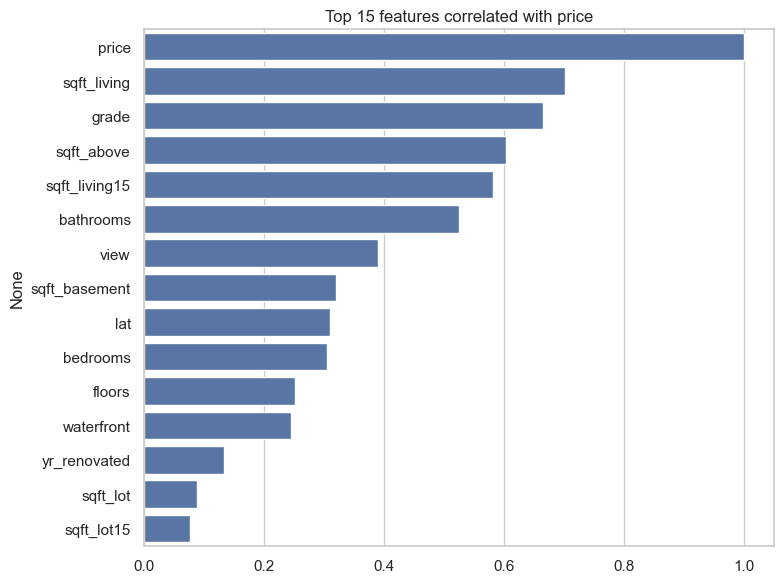

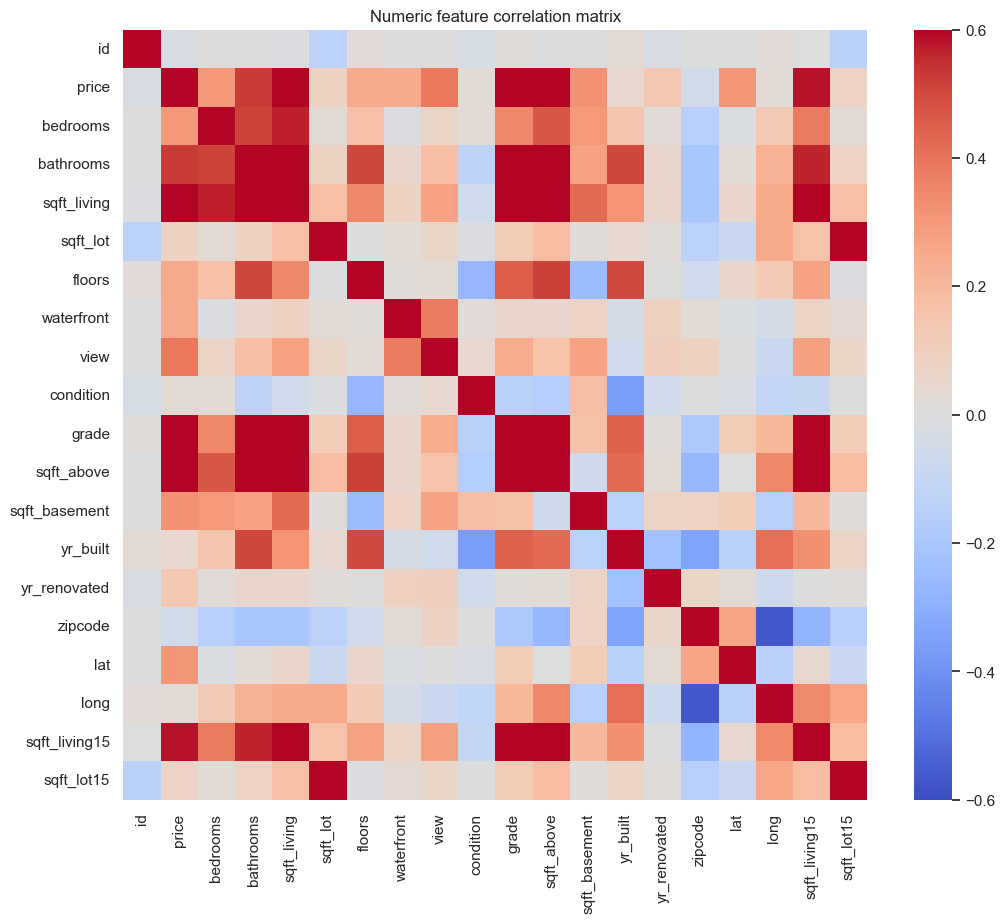

In [13]:
# === correlation with price + heatmap ===
num = train_df.select_dtypes(include=[np.number]).copy()
if 'price' not in num.columns:
    raise ValueError("price column missing")

corr_with_price = num.corr()['price'].sort_values(ascending=False)
print("Top correlations with price:\n", corr_with_price.head(20))

plt.figure(figsize=(8,6))
sns.barplot(x=corr_with_price.head(15).values, y=corr_with_price.head(15).index)
plt.title("Top 15 features correlated with price")
plt.tight_layout()
plt.show()

plt.figure(figsize=(12,10))
sns.heatmap(num.corr(), cmap='coolwarm', center=0, vmax=0.6, vmin=-0.6)
plt.title("Numeric feature correlation matrix")
plt.show()


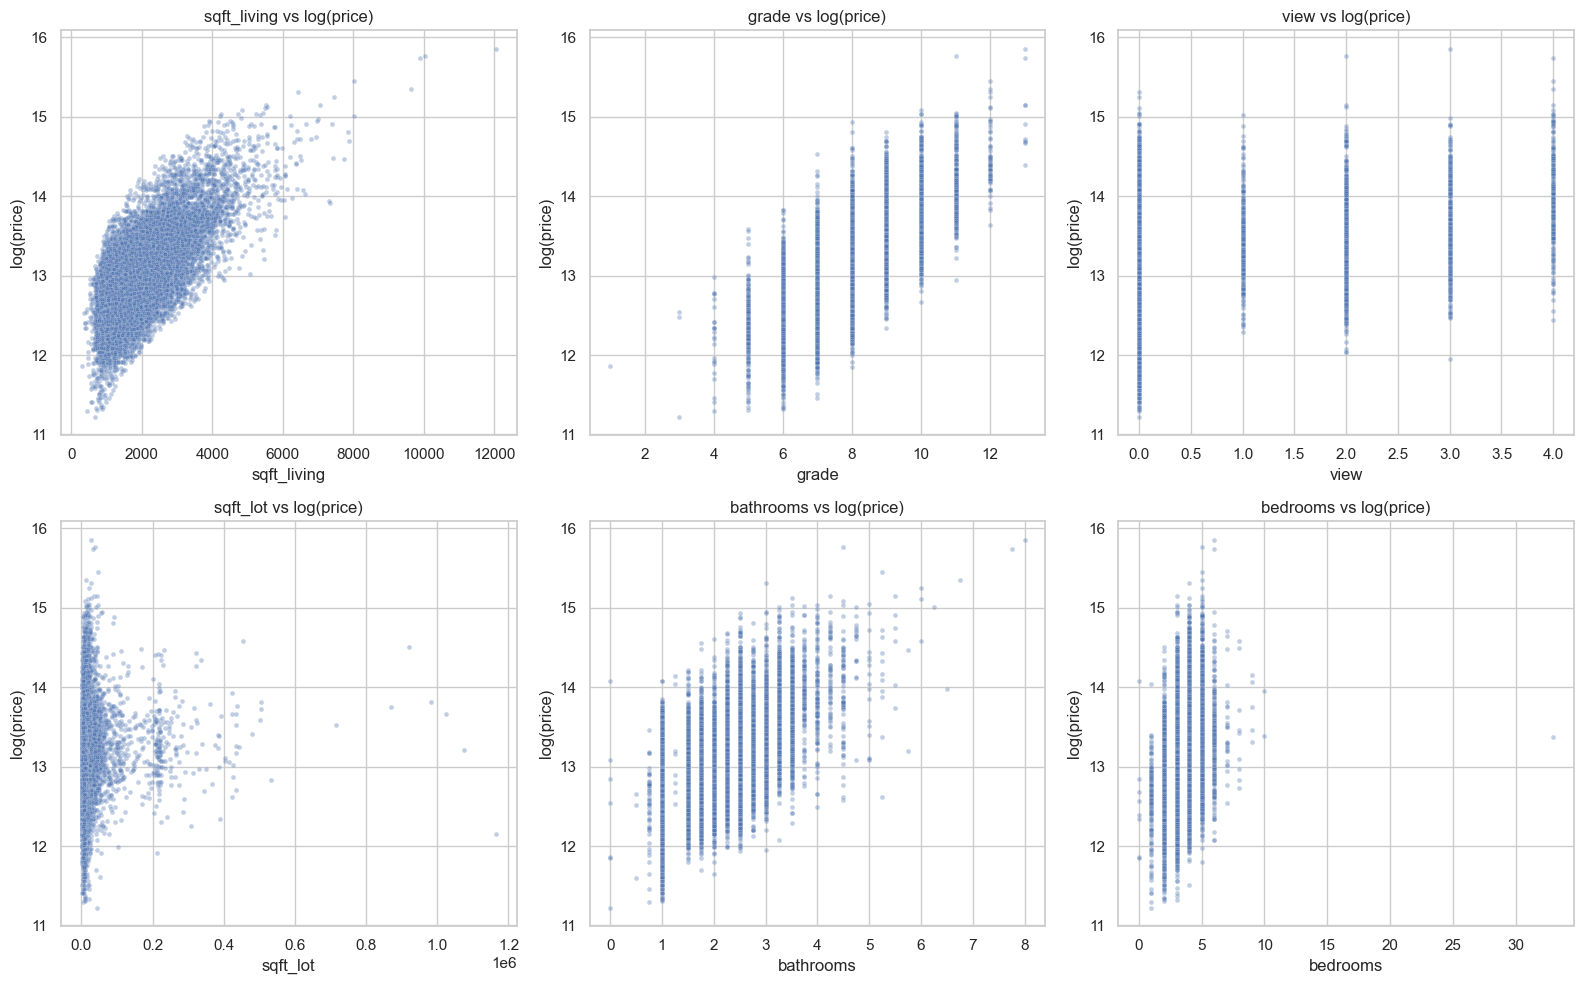

In [15]:
# === scatter plots for top predictors ===
top_feats = ['sqft_living','grade','view','sqft_lot','bathrooms','bedrooms']
top_feats = [c for c in top_feats if c in train_df.columns]

fig, axes = plt.subplots(2,3, figsize=(16,10))
axes = axes.flatten()
for ax, col in zip(axes, top_feats):
    sns.scatterplot(x=train_df[col].values, y=np.log1p(train_df['price']), alpha=0.35, s=12, ax=ax)
    ax.set_xlabel(col)
    ax.set_ylabel('log(price)')
    ax.set_title(f"{col} vs log(price)")
plt.tight_layout()
plt.show()


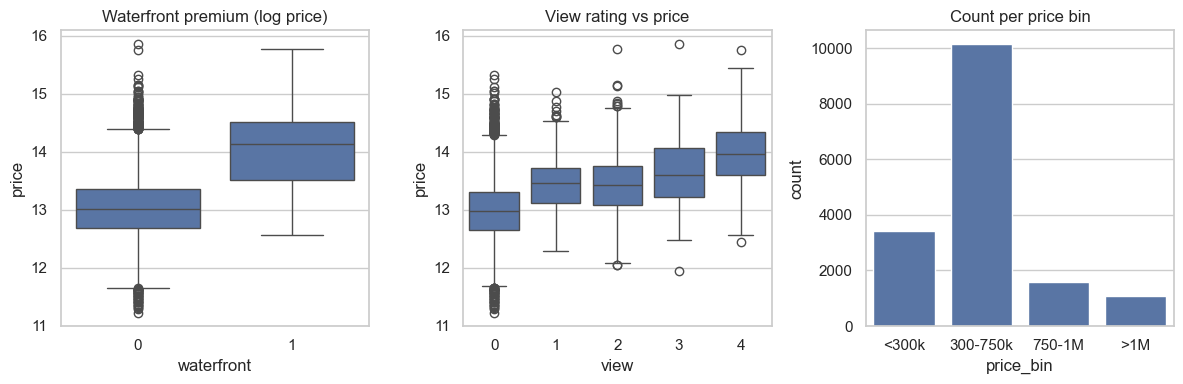

In [16]:
# === special segments boxplots and counts ===
plt.figure(figsize=(12,4))
if 'waterfront' in train_df.columns:
    plt.subplot(1,3,1)
    sns.boxplot(x=train_df['waterfront'], y=np.log1p(train_df['price']))
    plt.title('Waterfront premium (log price)')
else:
    print("No 'waterfront' column found")

plt.subplot(1,3,2)
if 'view' in train_df.columns:
    sns.boxplot(x=train_df['view'], y=np.log1p(train_df['price']))
    plt.title('View rating vs price')
else:
    print("No 'view' column found")

plt.subplot(1,3,3)
# Price buckets
bins = [0,300000,750000,1000000,train_df['price'].max()]
labels = ['<300k','300-750k','750-1M','>1M']
train_df['price_bin'] = pd.cut(train_df['price'], bins=bins, labels=labels, include_lowest=True)
sns.countplot(x='price_bin', data=train_df)
plt.title('Count per price bin')
plt.tight_layout()
plt.show()


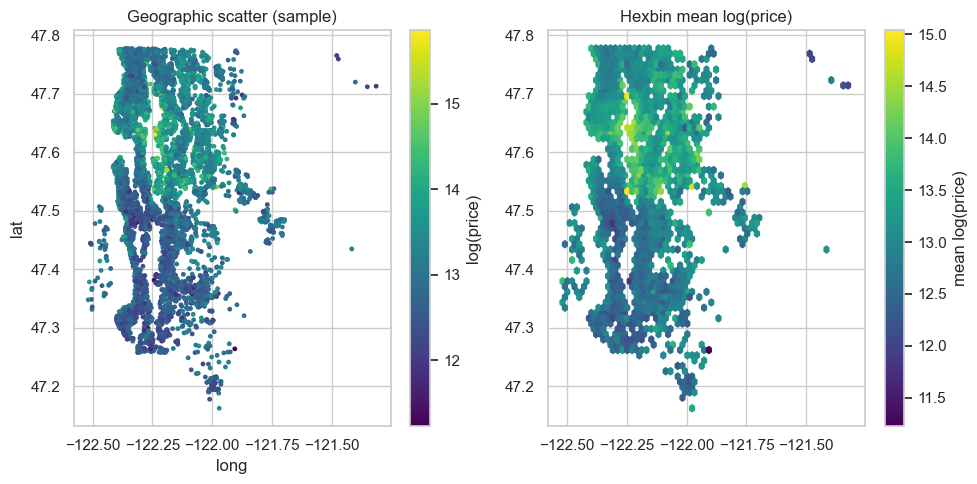

In [17]:
# === lat/long geospatial plots ===
sample = train_df.sample(min(8000, len(train_df)), random_state=42)
plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
sc = plt.scatter(sample['long'], sample['lat'], c=np.log1p(sample['price']), s=6, cmap='viridis')
plt.colorbar(sc, label='log(price)')
plt.title('Geographic scatter (sample)')
plt.xlabel('long'); plt.ylabel('lat')

plt.subplot(1,2,2)
hb = plt.hexbin(sample['long'], sample['lat'], C=np.log1p(sample['price']), reduce_C_function=np.mean, gridsize=60, cmap='viridis')
plt.colorbar(hb, label='mean log(price)')
plt.title('Hexbin mean log(price)')
plt.tight_layout()
plt.show()


,count,median,mean
geo_cluster,,,
4,1065,744000.0,872386.897653
1,1064,640000.0,792983.605263
5,1093,638150.0,683226.268984
17,638,615000.0,653600.564263
9,1563,562500.0,634607.994242
2,522,520000.0,564276.689655
8,1121,481500.0,600296.594112
7,440,462500.0,498834.940909
18,994,440000.0,570351.124748


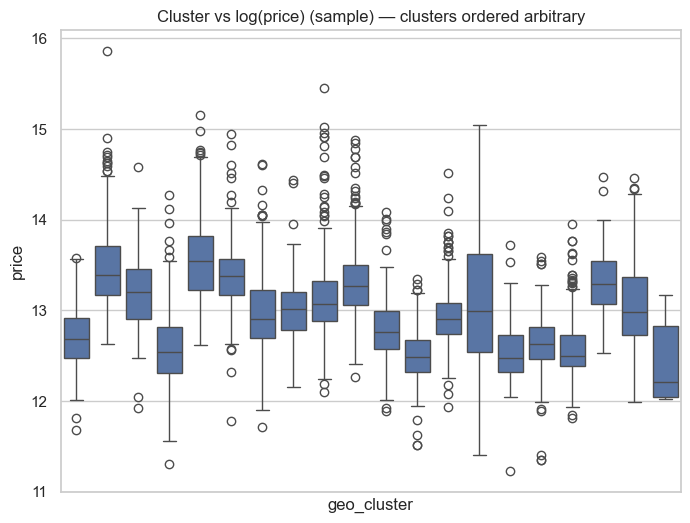

In [18]:
# === KMeans on lat/long to create clusters and cluster price stats ===
coords = train_df[['lat','long']].dropna().values
k = 20
kmeans = KMeans(n_clusters=k, random_state=42, n_init=10).fit(coords)
train_df['geo_cluster'] = kmeans.predict(train_df[['lat','long']].fillna(0).values)

cluster_stats = train_df.groupby('geo_cluster')['price'].agg(['count','median','mean']).sort_values('median', ascending=False)
display(cluster_stats.head(10))

plt.figure(figsize=(8,6))
sns.boxplot(x='geo_cluster', y=np.log1p(train_df['price']), data=train_df.sample(5000, random_state=42))
plt.xticks([],[])
plt.title('Cluster vs log(price) (sample) — clusters ordered arbitrary')
plt.show()


---
## 3. Visual Insights: Why Satellite Imagery Matters
---

**Key Question**: Can satellite images explain price differences that tabular features cannot?

We demonstrate this with:
1. **Matched Properties**: Similar sqft/bedrooms but very different prices
2. **Waterfront vs Non-Waterfront**: Visual differences driving premium
3. **Geospatial Price Distribution**: Spatial clustering of values

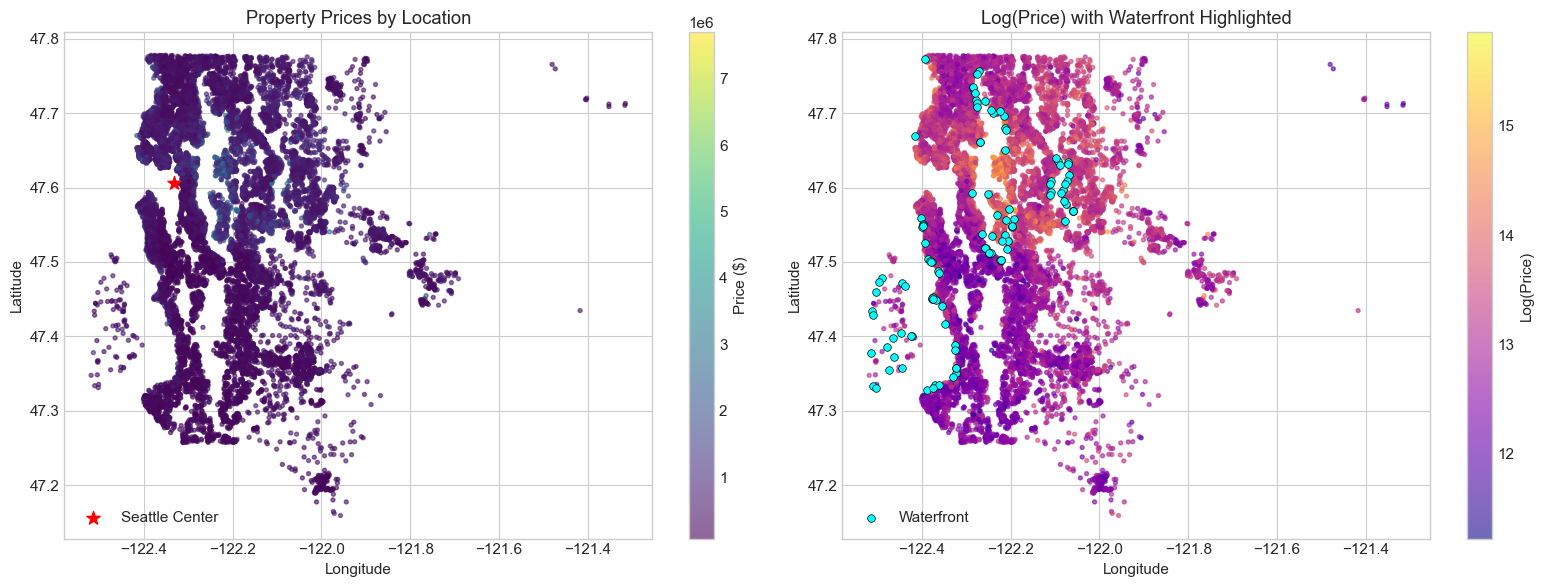


📊 GEOSPATIAL INSIGHT:
   - High-value properties cluster near water (west/northwest)
   - Clear price gradients from urban center outward
   - Satellite imagery captures these spatial patterns implicitly


In [6]:
# ==========================================================================
# GEOSPATIAL PRICE DISTRIBUTION
# ==========================================================================

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Left: All properties colored by price
ax1 = axes[0]
sc1 = ax1.scatter(train_df['long'], train_df['lat'], 
                  c=train_df['price'], s=8, cmap='viridis', alpha=0.6)
ax1.set_xlabel('Longitude')
ax1.set_ylabel('Latitude')
ax1.set_title('Property Prices by Location')
cbar1 = plt.colorbar(sc1, ax=ax1)
cbar1.set_label('Price ($)')
ax1.scatter([SEATTLE_CENTER_LONG], [SEATTLE_CENTER_LAT], 
           c='red', s=100, marker='*', label='Seattle Center', zorder=5)
ax1.legend()

# Right: Highlight waterfront
ax2 = axes[1]
sc2 = ax2.scatter(train_df['long'], train_df['lat'], 
                  c=np.log1p(train_df['price']), s=8, cmap='plasma', alpha=0.6)
ax2.set_xlabel('Longitude')
ax2.set_ylabel('Latitude')
ax2.set_title('Log(Price) with Waterfront Highlighted')
cbar2 = plt.colorbar(sc2, ax=ax2)
cbar2.set_label('Log(Price)')

# Highlight waterfront
wf_mask = train_df['waterfront'] == 1
ax2.scatter(train_df.loc[wf_mask, 'long'], train_df.loc[wf_mask, 'lat'],
           c='cyan', s=30, marker='o', edgecolors='black', linewidths=0.5,
           label='Waterfront', zorder=5)
ax2.legend()

plt.tight_layout()
plt.savefig(RESULTS_DIR / 'geospatial_distribution.png', dpi=150)
plt.show()

print("\n📊 GEOSPATIAL INSIGHT:")
print("   - High-value properties cluster near water (west/northwest)")
print("   - Clear price gradients from urban center outward")
print("   - Satellite imagery captures these spatial patterns implicitly")

In [7]:
# ==========================================================================
# SATELLITE IMAGE AVAILABILITY CHECK
# ==========================================================================

def check_image_availability(image_dir, df, zoom_levels=[16, 17, 18]):
    """Check how many satellite images are available."""
    results = {}
    
    for zoom in zoom_levels:
        zoom_dir = Path(image_dir) / f'zoom_{zoom}'
        if not zoom_dir.exists():
            results[f'zoom_{zoom}'] = {'found': 0, 'missing': len(df), 'pct': 0}
            continue
        
        found = 0
        for idx, row in df.iterrows():
            pid = row['id']
            for ext in ['.jpg', '.png']:
                if (zoom_dir / f'{pid}_z{zoom}{ext}').exists():
                    found += 1
                    break
        
        results[f'zoom_{zoom}'] = {
            'found': found, 
            'missing': len(df) - found, 
            'pct': found / len(df) * 100
        }
    
    return results

print("Checking satellite image availability...")
print(f"Looking in: {IMAGES_DIR}")

if IMAGES_DIR.exists():
    availability = check_image_availability(IMAGES_DIR, train_df)
    
    print("\nImage Availability:")
    print("="*50)
    for zoom, stats in availability.items():
        print(f"  {zoom}: {stats['found']}/{len(train_df)} ({stats['pct']:.1f}%)")
    
    if all(stats['pct'] > 95 for stats in availability.values()):
        print("\n✅ Excellent image coverage!")
    elif any(stats['pct'] > 0 for stats in availability.values()):
        print("\n⚠️ Partial image coverage. Run data_fetcher.py to download remaining images.")
    else:
        print("\n❌ No images found. Run: python data_fetcher.py --fetch-all")
else:
    print(f"\n❌ Images directory not found: {IMAGES_DIR}")
    print("   Run: python data_fetcher.py --fetch-all")

Checking satellite image availability...
Looking in: data\images

Image Availability:
  zoom_16: 16209/16209 (100.0%)
  zoom_17: 16209/16209 (100.0%)
  zoom_18: 16209/16209 (100.0%)

✅ Excellent image coverage!


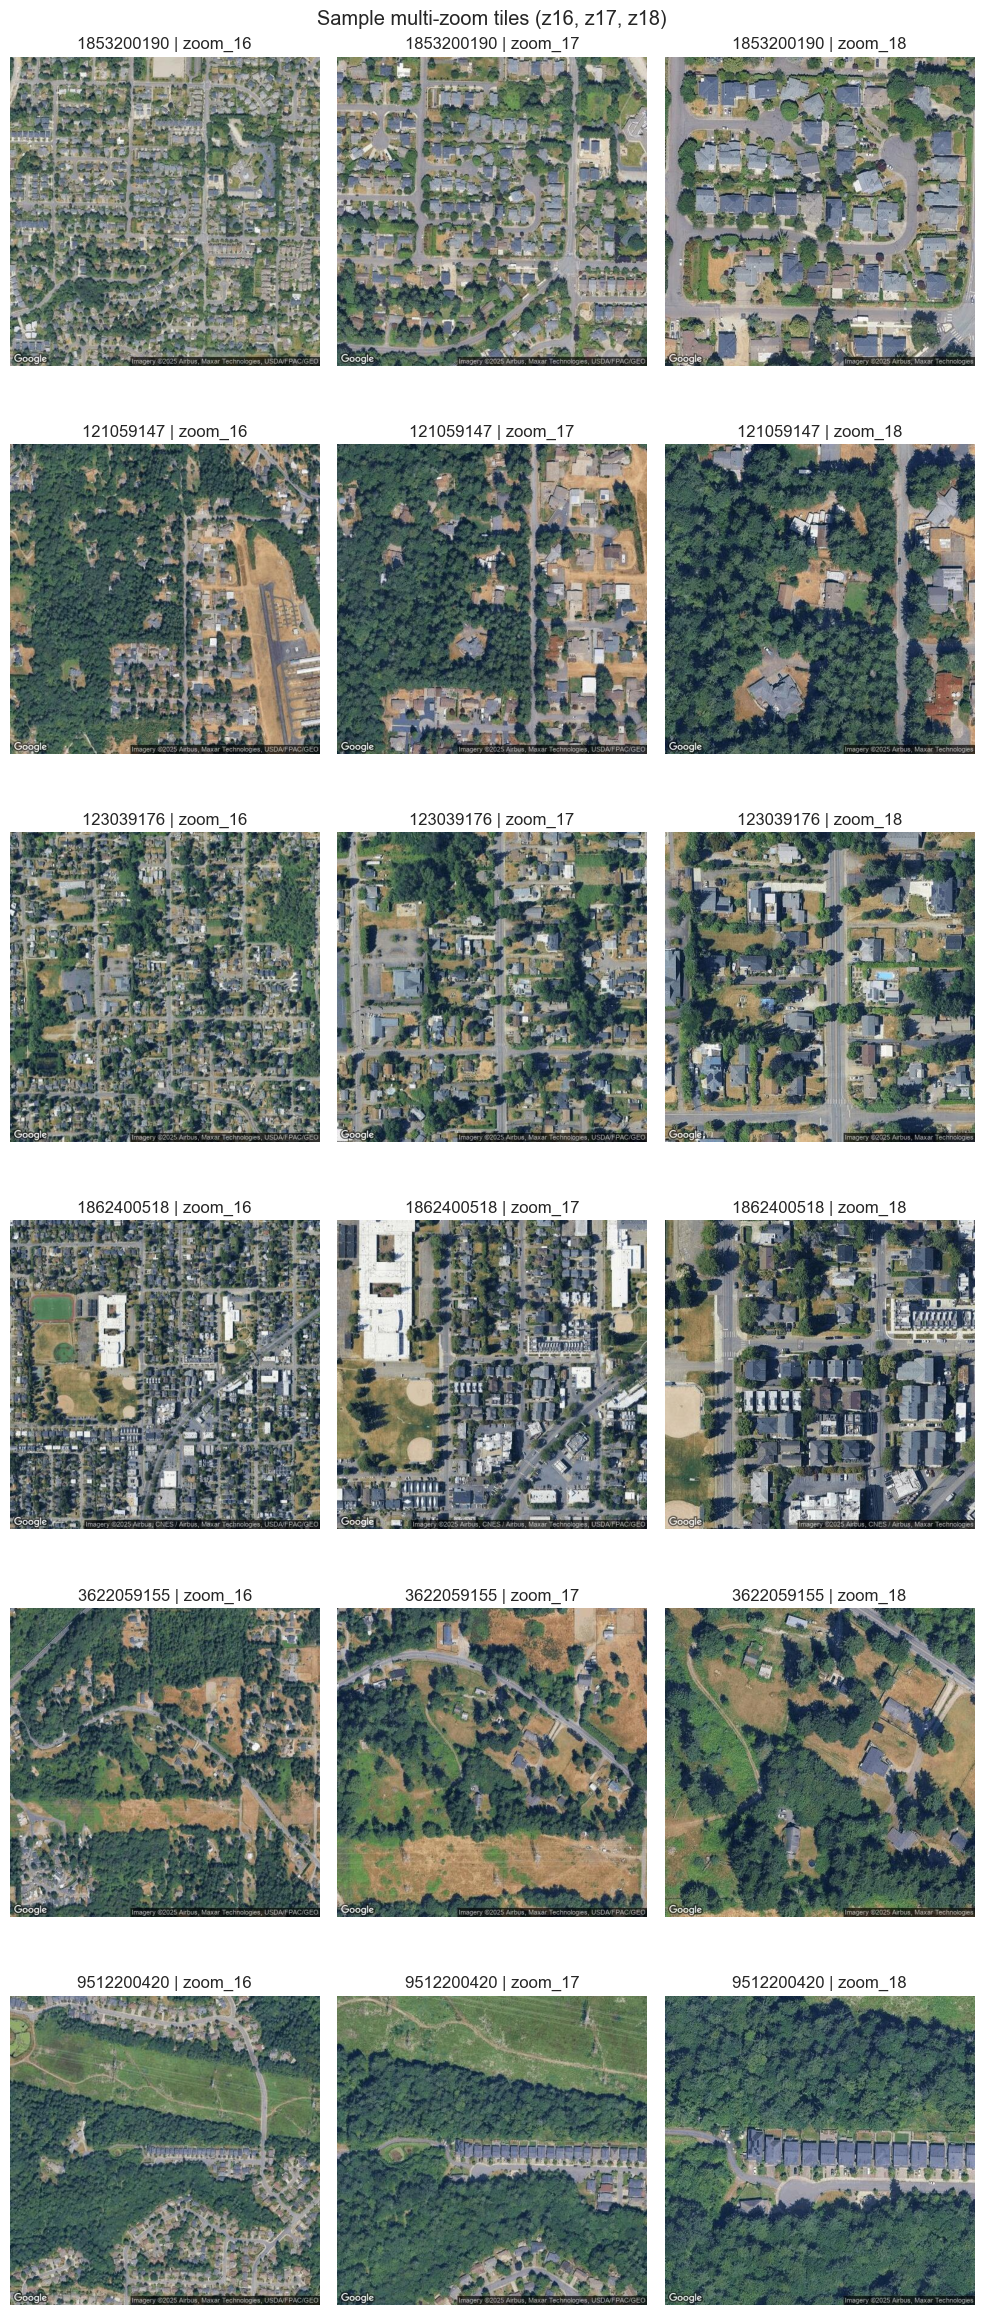

In [21]:
# === show triplets (z16, z17, z18) for a few sample ids ===
from math import ceil

def find_img(zoom_dir, pid):
    p1 = zoom_dir / f"{pid}.jpg"
    p2 = zoom_dir / f"{pid}_z{zoom_dir.name.split('_')[-1]}.jpg"  # try pattern like id_z18
    if p1.exists(): return p1
    if p2.exists(): return p2
    # sometimes named <id>_z18.jpg or <id>_z17
    for p in zoom_dir.glob(f"{pid}*"):
        return p
    return None

sample_ids = list(train_df['id'].sample(6, random_state=42).values)
n = len(sample_ids)
fig, axes = plt.subplots(n, 3, figsize=(10, 4*n))
for i, pid in enumerate(sample_ids):
    for j, zoom_dir in enumerate([IMAGES_ZOOM_16_DIR, IMAGES_ZOOM_17_DIR, IMAGES_ZOOM_18_DIR]):
        img_path = find_img(zoom_dir, pid)
        ax = axes[i, j]
        if img_path and img_path.exists():
            ax.imshow(Image.open(img_path).convert('RGB'))
            ax.set_title(f"{pid} | {zoom_dir.name}")
        else:
            ax.text(0.5,0.5,"Missing", ha='center', va='center')
        ax.axis('off')
plt.suptitle("Sample multi-zoom tiles (z16, z17, z18)")
plt.tight_layout()
plt.show()


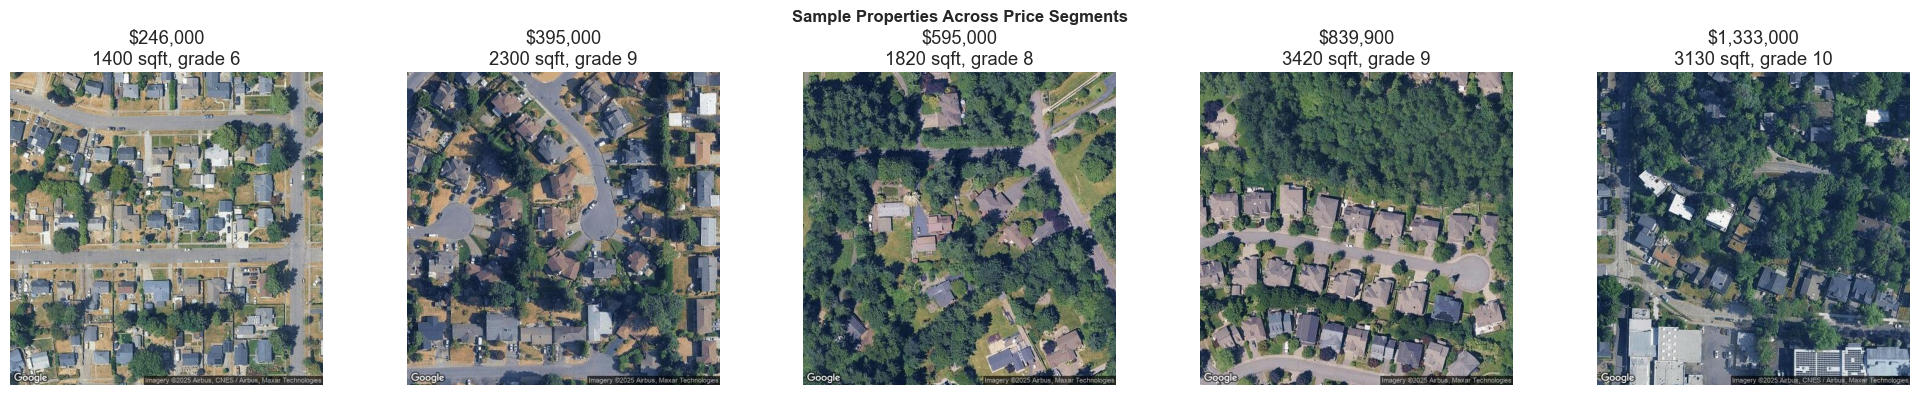


✅ Displayed 5/5 sample images


In [8]:
# ==========================================================================
# DISPLAY SAMPLE SATELLITE IMAGES
# ==========================================================================

def find_image(pid, images_dir, zoom=18):
    """Find satellite image for a property."""
    zoom_dir = Path(images_dir) / f'zoom_{zoom}'
    for ext in ['.jpg', '.png']:
        path = zoom_dir / f'{pid}_z{zoom}{ext}'
        if path.exists():
            return path
    return None

# Sample properties across price ranges
sample_indices = []
for segment_name, mask in segments:
    segment_df = train_df[mask]
    if len(segment_df) > 0:
        # Get property near median price for this segment
        median_price = segment_df['price'].median()
        closest_idx = (segment_df['price'] - median_price).abs().idxmin()
        sample_indices.append(closest_idx)

if len(sample_indices) > 0 and IMAGES_DIR.exists():
    fig, axes = plt.subplots(1, len(sample_indices), figsize=(4*len(sample_indices), 4))
    if len(sample_indices) == 1:
        axes = [axes]
    
    images_found = 0
    for i, idx in enumerate(sample_indices):
        ax = axes[i]
        row = train_df.loc[idx]
        
        img_path = find_image(row['id'], IMAGES_DIR, zoom=18)
        if img_path:
            img = Image.open(img_path)
            ax.imshow(img)
            images_found += 1
        else:
            ax.text(0.5, 0.5, 'No Image', ha='center', va='center', transform=ax.transAxes)
        
        ax.set_title(f"${int(row['price']):,}\n{int(row['sqft_living'])} sqft, grade {int(row['grade'])}")
        ax.axis('off')
    
    plt.suptitle('Sample Properties Across Price Segments', fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.savefig(RESULTS_DIR / 'sample_properties.png', dpi=150)
    plt.show()
    
    if images_found > 0:
        print(f"\n✅ Displayed {images_found}/{len(sample_indices)} sample images")
    else:
        print("\n⚠️ No images found for samples. Run data_fetcher.py first.")
else:
    print("Skipping image display - images not available.")

---
## 4. Next Steps: Running the Pipeline
---

### Step 1: Download Satellite Images (if not already done)

```bash
export GOOGLE_MAPS_API_KEY="your_api_key"
python data_fetcher.py --fetch-all
```

### Step 2: Run Baseline Model

```bash
python train_baseline_final.py
```

Expected output: `results/baseline_oof_predictions.csv` with **$119,160 RMSE**

### Step 3: Extract CNN Features

This should be done using the feature extraction in `extract_multi_encoder_features.py`.
Features are saved to `features/combined_features_{encoder}.pkl`

### Step 4: Run Fusion Model

```bash
python train_final.py --project-root . --n-seeds 25
```


Expected output: **$111,294 RMSE** (6.6% improvement)

In [9]:
# ==========================================================================
# SUMMARY STATISTICS FOR DOCUMENTATION
# ==========================================================================

print("="*60)
print("PREPROCESSING SUMMARY")
print("="*60)

print(f"\n📊 Dataset: {len(train_df):,} training samples")
print(f"\n💰 Price Range: ${train_df['price'].min():,.0f} - ${train_df['price'].max():,.0f}")
print(f"   Median: ${train_df['price'].median():,.0f}")

print(f"\n🏠 Key Segments:")
for name, mask in segments:
    count = mask.sum()
    pct = count / len(train_df) * 100
    print(f"   {name}: {count:,} ({pct:.1f}%)")

print(f"\n🌊 Waterfront: {(train_df['waterfront']==1).sum()} properties")
print(f"   Premium: {train_df[train_df['waterfront']==1]['price'].median() / train_df[train_df['waterfront']==0]['price'].median():.1f}x")

print(f"\n✅ Ready for model training!")
print(f"   1. Run: python train_baseline_final.py")
print(f"   2. Run: python train_final.py --n-seeds 25")

PREPROCESSING SUMMARY

📊 Dataset: 16,209 training samples

💰 Price Range: $75,000 - $7,700,000
   Median: $450,000

🏠 Key Segments:
   <$300K: 3,330 (20.5%)
   $300-500K: 6,008 (37.1%)
   $500-750K: 4,156 (25.6%)
   $750K-1M: 1,624 (10.0%)
   >$1M: 1,091 (6.7%)

🌊 Waterfront: 113 properties
   Premium: 3.0x

✅ Ready for model training!
   1. Run: python train_baseline_final.py
   2. Run: python train_final.py --n-seeds 25
